## Classificatore RealeSintetico — ResNet-50 con Fine-Tuning

Classificatore binario (cancro / non cancro) su mammografie con **ResNet-50** (ImageNet) e training in due fasi:

1. **Head Training** — backbone congelato, solo la custom head (GAP → Dense(256) → BN → LeakyReLU → Dropout(0.5) → sigmoid). Loss: `BinaryCrossentropy`, class weights bilanciati, Adam lr=1e-3.
2. **Fine-Tuning** — tutti i livelli sono scongelati e addestrabili. Loss: `BinaryFocalCrossentropy` (γ=2, α=0.75), Adam lr=1e-5 con ReduceLROnPlateau.

Valutazione con soglia ottimale (indice di Youden), metriche su validation set e Grad-CAM per l'interpretabilità.

I dati di train utilizzati per l'addestramento del modello sono dati reali preprocessati + dati sintetici generati dal diffusore ottenuto da fine-tuning


In [ ]:
import os
import sys

# Controlla se il notebook sta girando su Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
else:
    print("Ambiente locale rilevato.")
    BASE_PATH = '../'

print(f"Percorso base: ", BASE_PATH)

Ambiente locale rilevato.
Percorso base:  ../


#### Import Librerie

In [2]:
import zipfile
import gdown
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from sklearn.utils.class_weight import compute_class_weight
from datetime import date

I0000 00:00:1781771594.704781   14578 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781771594.858927   14578 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781771597.284578   14578 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


#### Download immagini sintetiche (fine-tuned)

Scarica da Google Drive lo ZIP con le immagini sintetiche positive e negative, le estrae nelle rispettive cartelle e rimuove l'archivio.
Se le immagini sono già presenti in locale, il download viene saltato


In [3]:
DEST_DIR     = os.path.join(BASE_PATH, 'data', 'synthetic', 'fine_tuned')
DEST_DIR_POS = os.path.join(DEST_DIR, 'positive')
DEST_DIR_NEG = os.path.join(DEST_DIR, 'negative')
ZIP_PATH     = os.path.join(DEST_DIR, 'filtered_generated.zip')
SYNTHETIC_DRIVE_ID = '1NKXKcovSlS4-0_zznKmrg1nU0DiXhcFq'

# CONFIGURA QUI: nomi delle cartelle dentro lo ZIP
ZIP_FOLDER_POS = 'positive_filtered_1361_adaptive_mask'   # cartella nello ZIP che contiene le immagini POSITIVE (cancer=1)
ZIP_FOLDER_NEG = 'negative_filtered_1361_adaptive_mask'   # cartella nello ZIP che contiene le immagini NEGATIVE (cancer=0)

def synthetic_data_ready():
    if not os.path.isdir(DEST_DIR_POS) or not os.path.isdir(DEST_DIR_NEG):
        return False
    return (
        any(f.endswith('.png') for f in os.listdir(DEST_DIR_POS)) and
        any(f.endswith('.png') for f in os.listdir(DEST_DIR_NEG))
    )

os.makedirs(DEST_DIR, exist_ok=True)

if not synthetic_data_ready():
    import shutil, tempfile
    print("Immagini sintetiche non trovate, scarico da Google Drive...")
    gdown.download(id=SYNTHETIC_DRIVE_ID, output=ZIP_PATH, quiet=False)

    with tempfile.TemporaryDirectory() as tmp:
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(tmp)
        shutil.move(os.path.join(tmp, ZIP_FOLDER_POS), DEST_DIR_POS)
        shutil.move(os.path.join(tmp, ZIP_FOLDER_NEG), DEST_DIR_NEG)

    os.remove(ZIP_PATH)
    n_pos = sum(1 for f in os.listdir(DEST_DIR_POS) if f.endswith('.png'))
    n_neg = sum(1 for f in os.listdir(DEST_DIR_NEG) if f.endswith('.png'))
    print(f"Estrazione completata. File presenti:\n - Positivi: {n_pos}\n - Negativi: {n_neg}")
else:
    n_pos = sum(1 for f in os.listdir(DEST_DIR_POS) if f.endswith('.png'))
    n_neg = sum(1 for f in os.listdir(DEST_DIR_NEG) if f.endswith('.png'))
    print(f"Immagini sintetiche già presenti:\n - Positivi: {n_pos}\n - Negativi: {n_neg}")

Immagini sintetiche già presenti:
 - Positivi: 1361
 - Negativi: 1361


#### Verifica e download dataset preprocessato

Scarica da Google Drive il dataset reale preprocessato (immagini + CSV),
se non già presente in locale.

- Controllo presenza: verifica che esistano entrambi i CSV (`train.csv`, `val.csv`)
e che la prima immagine referenziata sia effettivamente sul disco.
Se il controllo passa, il download viene saltato.

- Se assente: scarica lo ZIP, lo estrae in `data/processed/` e rimuove l'archivio

In [ ]:
# ID del file su Google Drive
PROCESSED_DRIVE_ID = "1qQral_BIBlMl0QN3PllJukdYTOmNGWr3"

# Percorso del dataset preprocessato in .ZIP
PROCESSED_ZIP = os.path.join(BASE_PATH, 'data', 'processed', 'processed.zip')

# Percorso di train e validation csv
TRAIN_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "train.csv")
VAL_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "val.csv")

def processed_data_ready():
    if not os.path.isfile(TRAIN_CSV_PATH) or not os.path.isfile(VAL_CSV_PATH):
        return False
    try:
        first_path = pd.read_csv(TRAIN_CSV_PATH)['processed_path'].iloc[0]
        return os.path.isfile(os.path.join(BASE_PATH, first_path))
    except Exception:
        return False

if not processed_data_ready():
    print("Dataset non trovato, scarico da Google Drive...")
    os.makedirs(os.path.dirname(PROCESSED_ZIP), exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=PROCESSED_ZIP, quiet=False)
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(os.path.join(BASE_PATH, 'data', 'processed'))
    os.remove(PROCESSED_ZIP)
    print(f"Dataset estratto in: {os.path.join(BASE_PATH, 'data')}")
else:
    print("Dataset già presente, salto il download.")


Dataset già presente, salto il download.


#### Creazione CSV combinato (reale + sintetico)

Costruisce il training set combinato bilanciando le classi al 45% positivi / 55% negativi:
- Positivi: tutte le immagini reali positive + tutte le sintetiche positive
- Negativi: tutte le immagini reali negative + un sottoinsieme di sintetiche negative,
  campionato deterministicamente con `np.linspace` per coprire uniformemente la distribuzione


In [ ]:
# Percorso del csv in output
OUTPUT_PATH = os.path.join(BASE_PATH, 'data', 'synthetic', 'metadata', 'train_real_synthetic_ft.csv')
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

# Dati reali
df_real_train = pd.read_csv(TRAIN_CSV_PATH)

def fix_path(p):
    if os.path.isabs(p) or p.startswith('../') or p.startswith('./'):
        return p
    return os.path.join(BASE_PATH, p)

df_real_train['processed_path'] = df_real_train['processed_path'].apply(fix_path)

n_real_pos = (df_real_train['cancer'] == 1).sum()
n_real_neg = (df_real_train['cancer'] == 0).sum()

# Tutte le sintetiche positive
synth_pos_paths = sorted([
    os.path.join(DEST_DIR_POS, f)
    for f in os.listdir(DEST_DIR_POS) if f.endswith('.png')
])
n_synth_pos = len(synth_pos_paths)

# Logica di bilanciamento 45% positivi / 55% negativi
# tot_pos è fisso => rappresenta il 45% => calcola il totale e i negativi necessari
tot_pos = n_real_pos + n_synth_pos
tot_dataset = round(tot_pos / 0.45)
tot_neg_needed = tot_dataset - tot_pos
n_synth_neg_needed = max(0, tot_neg_needed - n_real_neg)

# Sintetiche negative: campionamento deterministico con indici equamente distanziati
synth_neg_paths_all = sorted([
    os.path.join(DEST_DIR_NEG, f)
    for f in os.listdir(DEST_DIR_NEG) if f.endswith('.png')
])
n_available = len(synth_neg_paths_all)

if n_synth_neg_needed > n_available:
    print(f"ATTENZIONE: richieste {n_synth_neg_needed} sintetiche negative, disponibili {n_available}. Uso tutte.")
    synth_neg_paths = synth_neg_paths_all
else:
    indices = np.linspace(0, n_available - 1, n_synth_neg_needed, dtype=int)
    synth_neg_paths = [synth_neg_paths_all[i] for i in indices]

# Costruzione DataFrame combinato
df_synth_pos_df = pd.DataFrame({'processed_path': synth_pos_paths, 'cancer': 1, 'type': 'generated_ft'})
df_synth_neg_df = pd.DataFrame({'processed_path': synth_neg_paths,  'cancer': 0, 'type': 'generated_ft'})

df_combined = pd.concat(
    [df_real_train.assign(type='real'), df_synth_pos_df, df_synth_neg_df],
    ignore_index=True
)
df_combined.to_csv(OUTPUT_PATH, index=False)

#### Analisi esplorativa del dataset combinato

Stampa tre grafici:
- Distribuzione globale delle classi (positivi / negativi)
- Numero di immagini per sorgente (`real` / `generated_ft`)
- Stacked bar: composizione per classe all'interno di ciascuna sorgente

  RIEPILOGO DATASET COMBINATO
  Totale immagini: 3780

              No cancro (0)  Cancro (1)  Totale  % cancer=1
Tipo                                                       
generated_ft            378        1361    1739        78.3
real                   1701         340    2041        16.7

  Totale Cancro (1):     1701  (45.0%)
  Totale No cancro (0):  2079  (55.0%)


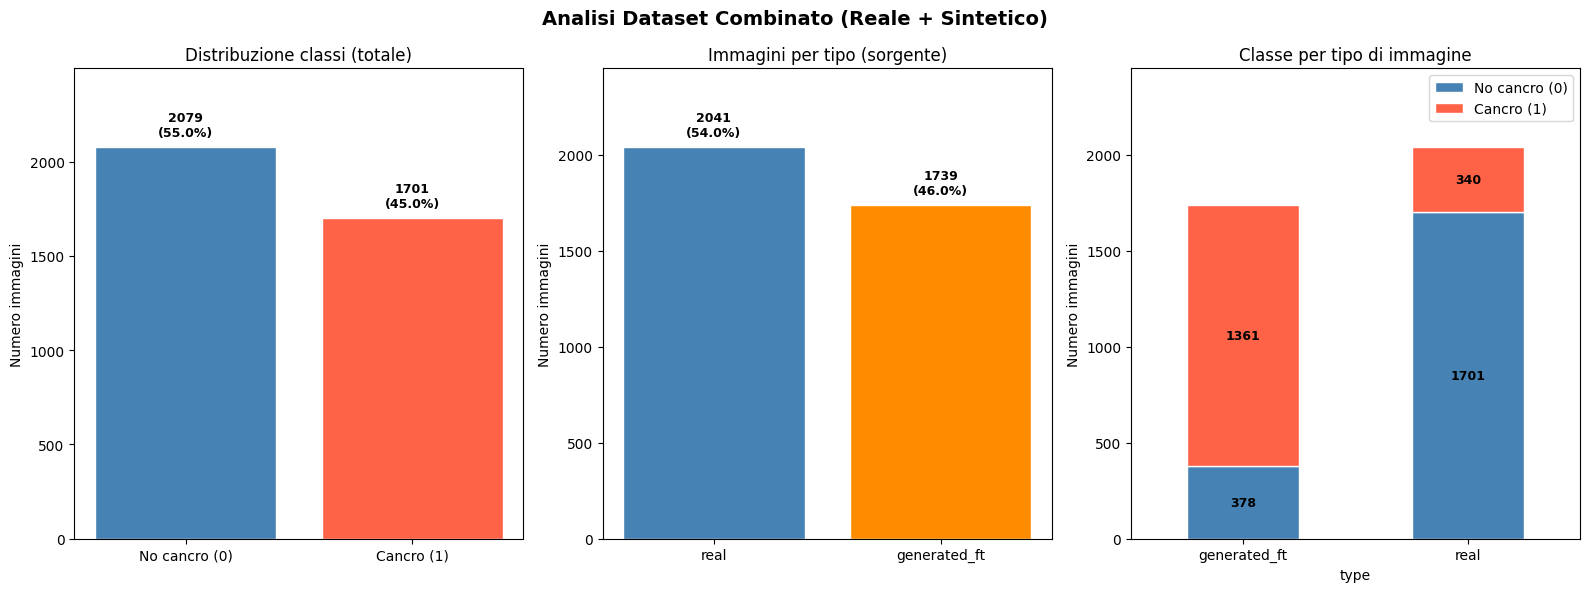

In [ ]:
df = df_combined
tot = len(df)

ct = pd.crosstab(df['type'], df['cancer'], rownames=['Tipo'], colnames=['cancer'])
ct.columns = ['No cancro (0)', 'Cancro (1)']
ct['Totale'] = ct.sum(axis=1)
ct['% cancer=1'] = (ct['Cancro (1)'] / ct['Totale'] * 100).round(1)
print(ct.to_string())
print()

n_pos = (df['cancer'] == 1).sum()
n_neg = (df['cancer'] == 0).sum()
print(f"  Totale Cancro (1):    {n_pos:>5}  ({n_pos/tot*100:.1f}%)")
print(f"  Totale No cancro (0): {n_neg:>5}  ({n_neg/tot*100:.1f}%)")
print("=" * 55)

# Grafici
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Analisi Dataset Combinato (Reale + Sintetico)", fontsize=14, fontweight='bold')

def label_bars(ax, bars, total, margin_frac=0.20):
    ymax = max(b.get_height() for b in bars)
    ax.set_ylim(0, ymax * (1 + margin_frac))
    for bar in bars:
        v = int(bar.get_height())
        ax.text(bar.get_x() + bar.get_width() / 2, v + ymax * 0.02,
                f"{v}\n({v/total*100:.1f}%)", ha='center', va='bottom',
                fontweight='bold', fontsize=9)

# Distribuzione classi globale
counts = df['cancer'].value_counts().sort_index()
bars = axes[0].bar(['No cancro (0)', 'Cancro (1)'], counts.values,
                   color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Distribuzione classi (totale)')
axes[0].set_ylabel('Numero immagini')
label_bars(axes[0], bars, tot)

# Distribuzione per tipo
type_counts = df['type'].value_counts()
bars2 = axes[1].bar(type_counts.index, type_counts.values,
                    color=['steelblue', 'darkorange'], edgecolor='white')
axes[1].set_title('Immagini per tipo (sorgente)')
axes[1].set_ylabel('Numero immagini')
label_bars(axes[1], bars2, tot)

# Stacked bar tipo x classe
ct_plot = pd.crosstab(df['type'], df['cancer'])
ct_plot.plot(kind='bar', stacked=True, ax=axes[2],
             color=['steelblue', 'tomato'], rot=0, edgecolor='white')
axes[2].set_title('Classe per tipo di immagine')
axes[2].set_ylabel('Numero immagini')
axes[2].legend(['No cancro (0)', 'Cancro (1)'], loc='upper right')
stacked_max = ct_plot.sum(axis=1).max()
axes[2].set_ylim(0, stacked_max * 1.20)
for container in axes[2].containers:
    axes[2].bar_label(container, label_type='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### Configurazione

In [7]:
# Cartella esperimento
OUTPUT_EXP_DIR = os.path.join(BASE_PATH, 'experiments', 'exp20260618_real_synth_resnet50_fine_tuned_all_layers')
os.makedirs(OUTPUT_EXP_DIR, exist_ok=True)
print(OUTPUT_EXP_DIR)

../experiments/exp20260618_real_synth_resnet50_fine_tuned_all_layers


In [ ]:
IMG_SIZE = (224, 224) # Dimensione standard ResNet-50
BATCH_SIZE = 16
SEED = 42

# Medie e std di ImageNet
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225])

# Imposta il seed per la riproducibilità
keras.utils.set_random_seed(SEED)
print(TRAIN_CSV_PATH)
print(VAL_CSV_PATH)

../data/processed/metadata/train.csv
../data/processed/metadata/val.csv


I0000 00:00:1781771608.656534   14578 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


#### Preparazione Dataset e Pipeline di Input

Carica i CSV di train e validation, calcola i **pesi delle classi** (bilanciamento del dataset sbilanciato tra casi positivi e negativi) e costruisce la pipeline `tf.data`.

**Preprocessing applicato ad ogni immagine:**
- Decodifica in scala di grigi (1 canale) e resize a `IMG_SIZE`
- Normalizzazione in `[0, 1]` e replica su 3 canali
- Standardizzazione con media e deviazione standard ImageNet

**Data Augmentation** (opzionale, al momento disabilitata): flip orizzontale e variazione casuale di luminosità. Escluse rotazioni verticali e zoom per non introdurre artefatti irrealistici nelle mammografie.

In [ ]:
# Carica e filtra il CSV
df_train = pd.read_csv(OUTPUT_PATH).reset_index(drop=True)
df_val = pd.read_csv(VAL_CSV_PATH).reset_index(drop=True)

def fix_path(p):
    if os.path.isabs(p) or p.startswith('../') or p.startswith('./'):
        return p
    return os.path.join(BASE_PATH, p)

df_train['processed_path'] = df_train['processed_path'].apply(fix_path)
df_val['processed_path'] = df_val['processed_path'].apply(fix_path)

# Calcola i pesi delle classi per il training
labels_train = df_train['cancer'].values
classes = np.unique(labels_train)
weights = compute_class_weight('balanced', classes=classes, y=labels_train)
class_weight_dict = dict(zip(classes.astype(int), weights))
print(f"Class Weights: {class_weight_dict}")

AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
        
    return img, tf.cast(label, tf.float32)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.clip_by_value(img, -3.0, 3.0)
    return img, label
# Niente rotazioni forti (come rotazione verticale), nemmeno zoom

def make_dataset(df, shuffle=False, augment_data=False):
    paths = df['processed_path'].values
    labels = df['cancer'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(lambda p, l: load_and_preprocess(p, l), num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Costruisci i dataset
train_ds = make_dataset(df_train, shuffle=True, augment_data=False)
val_ds = make_dataset(df_val, shuffle=False, augment_data=False) 

Class Weights: {0: 0.9090909090909091, 1: 1.1111111111111112}


#### Configurazione e Salvataggio dell'Esperimento

In [10]:
experiment_config = {
    "experiment_name": os.path.basename(OUTPUT_EXP_DIR),
    "date": date.today().isoformat(),
    "backbone": {
        "name": "ResNet-50",
        "weights": "imagenet",
        "input_shape": list(IMG_SIZE) + [3],
        "include_top": False,
    },
    "head": {
        "pooling": "GlobalAveragePooling2D",
        "dense_units": 256,
        "l2_regularization": 1e-4,
        "activation": "LeakyReLU(negative_slope=0.1)",
        "dropout": 0.5,
        "output": "Dense(1, sigmoid)",
    },
    "preprocessing": {
        "img_size": list(IMG_SIZE),
        "normalization": "ImageNet mean/std",
        "imagenet_mean": [0.485, 0.456, 0.406],
        "imagenet_std": [0.229, 0.224, 0.225],
    },
    "data": {
        "batch_size": BATCH_SIZE,
        "seed": SEED,
        "augmentation": False,
        "train_csv": OUTPUT_PATH,
        "val_csv": VAL_CSV_PATH,
    },
    "phase1_head_training": {
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "loss": "binary_crossentropy",
        "max_epochs": 25,
        "early_stopping_monitor": "val_auc",
        "early_stopping_patience": 7,
        "class_weight": "balanced",
        "backbone_trainable": False,
    },
    "phase2_fine_tuning": {
        "optimizer": "Adam",
        "learning_rate": 1e-5,
        "loss": "BinaryFocalCrossentropy",
        "BinaryFocalCrossentropy_gamma": 2.0,
        "BinaryFocalCrossentropy_alpha": 0.75,
        "max_epochs": 30,
        "fine_tune_from_layer": "all_layers",
        "early_stopping_monitor": "val_auc",
        "early_stopping_patience": 5,
        "early_stopping_min_delta": 1e-3,
        "reduce_lr_factor": 0.5,
        "reduce_lr_patience": 3,
        "min_lr": 1e-7,
        "class_weight": "none",
    },
}

config_path = os.path.join(OUTPUT_EXP_DIR, 'experiment_config.json')
with open(config_path, 'w') as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)
print(f"Configurazione esperimento salvata in: {config_path}")


Configurazione esperimento salvata in: ../experiments/exp20260618_real_synth_resnet50_fine_tuned_all_layers/experiment_config.json


#### Costruzione del Modello — Fase 1 (Head Training)

Il modello segue un'architettura **feature extractor + custom head**:

- **Backbone**: ResNet-50 pre-addestrato su ImageNet, congelato (`trainable=False`)
- **Head**: GlobalAveragePooling → Dense(256) con L2 + BatchNorm + LeakyReLU + Dropout(0.5) → uscita sigmoidea per classificazione binaria

`training=False` nel forward pass del backbone mantiene le sue BatchNorm in modalità inferenza anche durante il training, evitando di corrompere le statistiche apprese.

La funzione restituisce sia `model` che `base_model` per permettere lo sblocco selettivo dei layer nella fase di fine-tuning.


In [ ]:
def build_base_model():
    # Carica il backbone ResNet-50 pre-addestrato
    base_model = keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=IMG_SIZE + (3,)
    )
    
    # Congela il backbone per l'addestramento della Custom Head
    base_model.trainable = False
    
    # Costruzione dell'architettura completa
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    
    x = base_model(inputs, training=False) 
    
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x) 
    x = layers.Dropout(0.5)(x)
    
    # Sigmoide per classificazione binaria    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs, name="real_synth_resnet50_all_layers")
    return model, base_model

model, base_model = build_base_model()
model.summary()

Model: "real_synth_resnet50_all_layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,537 (91.99 MB)

 Trainable params: 525,313 (2.00 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

#### Compilazione e Training — Fase 1 (Head Training)

Il backbone rimane congelato: si addestrano solo i layer della custom head.

- **Loss**: `binary_crossentropy` — classificazione binaria (cancro / non cancro)
- **Metrica principale**: AUC — più robusta dell'accuracy su dataset sbilanciati
- **Class weight**: penalizza gli errori sulla classe minoritaria (casi positivi)
- **Early stopping**: patience 7 epoche su `val_auc`


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision')
    ]
)

callbacks_fase1 = [
    # Monitor su val_auc: metrica più robusta dell'accuracy per dataset sbilanciati
    keras.callbacks.EarlyStopping(
        monitor='val_auc', 
        patience=7, 
        restore_best_weights=True, 
        mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_EXP_DIR, 'real_synth_resnet50_all_layers_fase1_best.keras'), 
        monitor='val_auc', 
        save_best_only=True, 
        mode='max'
    ),
    keras.callbacks.CSVLogger(
        os.path.join(OUTPUT_EXP_DIR, 'training_log_fase1.csv'),
        separator=',',
        append=False
    )
]

history_phase1 = model.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    class_weight=class_weight_dict, # Compensa lo sbilanciamento del train set
    callbacks=callbacks_fase1
)

Epoch 1/25


I0000 00:00:1781771653.386977   14713 service.cc:153] XLA service 0x768c1406b750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781771653.387075   14713 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1781771653.999087   14713 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781771656.719093   14713 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1781771656.901190   14713 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12190__.197
I0000 00:00:1781771668.544633   14713 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6814 - auc: 0.7278 - loss: 0.7284 - precision: 0.6284 - recall: 0.6577

I0000 00:00:1781771680.808365   14709 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12190__.197


237/237 ━━━━━━━━━━━━━━━━━━━━ 61s 158ms/step - accuracy: 0.6944 - auc: 0.7457 - loss: 0.6891 - precision: 0.6493 - recall: 0.6978 - val_accuracy: 0.7666 - val_auc: 0.6143 - val_loss: 0.5284 - val_precision: 0.2041 - val_recall: 0.1370
Epoch 2/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.7204 - auc: 0.7805 - loss: 0.6210 - precision: 0.6752 - recall: 0.7296 - val_accuracy: 0.7872 - val_auc: 0.6189 - val_loss: 0.5359 - val_precision: 0.2727 - val_recall: 0.1644
Epoch 3/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.7294 - auc: 0.7955 - loss: 0.5923 - precision: 0.6842 - recall: 0.7402 - val_accuracy: 0.7391 - val_auc: 0.6412 - val_loss: 0.5737 - val_precision: 0.2530 - val_recall: 0.2877
Epoch 4/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.7466 - auc: 0.8050 - loss: 0.5784 - precision: 0.7014 - recall: 0.7607 - val_accuracy: 0.7872 - val_auc: 0.6271 - val_loss: 0.5121 - val_precision: 0.2619 - val_recall: 0.1507
Epoch 5/25
237/237 ━━━━━━━━━━━━━━━

W0000 00:00:1781771808.173042   14922 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 16777600 bytes after encountering the first element of size 16777600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


237/237 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.7714 - auc: 0.8350 - loss: 0.5389 - precision: 0.7288 - recall: 0.7837 - val_accuracy: 0.7941 - val_auc: 0.6339 - val_loss: 0.5053 - val_precision: 0.2703 - val_recall: 0.1370
Epoch 12/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.7696 - auc: 0.8335 - loss: 0.5412 - precision: 0.7275 - recall: 0.7801 - val_accuracy: 0.7712 - val_auc: 0.6023 - val_loss: 0.5439 - val_precision: 0.2545 - val_recall: 0.1918
Epoch 13/25
237/237 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.7704 - auc: 0.8421 - loss: 0.5315 - precision: 0.7295 - recall: 0.7784 - val_accuracy: 0.7277 - val_auc: 0.6286 - val_loss: 0.5800 - val_precision: 0.2326 - val_recall: 0.2740


#### Fine-Tuning — Fase 2 (Sblocco Totale del Backbone)

Il backbone viene totalmente sbloccato
- **Loss**: `BinaryFocalCrossentropy` — penalizza gli esempi difficili (`gamma=2`) e bilancia le classi (`alpha=0.75` al cancro)
- **class_weight rimosso**: il bilanciamento è già gestito da `apply_class_balancing=True`; applicarli insieme duplicherebbe la correzione
- **LR = 1e-5**: ordine di grandezza inferiore alla fase 1 per aggiornamenti graduali sui pesi pre-addestrati
- **ReduceLROnPlateau**: dimezza il LR se `val_auc` non migliora per 3 epoche, fino a un minimo di `1e-7`


In [ ]:
base_model.trainable = True

print(f"Totale layer nel base_model: {len(base_model.layers)}")
n_trainable_layers = sum(1 for l in base_model.layers if l.trainable)
print(f"Layer trainable nel base_model: {n_trainable_layers}/{len(base_model.layers)}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), # Learning Rate basso per non distruggere i pesi ImageNet nei layer sbloccati
    loss=keras.losses.BinaryFocalCrossentropy(
        apply_class_balancing=True,
        alpha=0.75, # Peso alla classe positiva (cancer): 0.75 vs 0.25 per i negativi
        gamma=2.0, # Riduce il peso degli esempi già ben classificati
        from_logits=False
    ),
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision')
    ]
)

callbacks_fase2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', 
        patience=5,
        min_delta=1e-3,
        restore_best_weights=True, 
        mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_EXP_DIR, 'real_synth_resnet50_all_layers_final_best.keras'), 
        monitor='val_auc',
        save_best_only=True, 
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', 
        factor=0.5, 
        patience=3,
        mode='max', 
        min_lr=1e-7
    ),
    keras.callbacks.CSVLogger(
        os.path.join(OUTPUT_EXP_DIR, 'training_log_fase2.csv'),
        separator=',',
        append=False
    )
]

history_phase2 = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    #class_weight=class_weight_dict,
    callbacks=callbacks_fase2
)

print(f"\nTraining completato. Il miglior modello è salvato in: {os.path.join(OUTPUT_EXP_DIR, 'real_synth_resnet50_all_layers_final_best.keras')}")

Totale layer nel base_model: 175
Layer trainable nel base_model: 175/175
Epoch 1/30


I0000 00:00:1781771910.128389   14709 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_90800__.409


236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.7071 - auc: 0.7783 - loss: 0.2074 - precision: 0.6631 - recall: 0.7196

I0000 00:00:1781771988.324072   14708 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_90800__.409


237/237 ━━━━━━━━━━━━━━━━━━━━ 185s 398ms/step - accuracy: 0.7151 - auc: 0.7855 - loss: 0.1815 - precision: 0.6637 - recall: 0.7437 - val_accuracy: 0.7918 - val_auc: 0.5535 - val_loss: 0.2948 - val_precision: 0.1538 - val_recall: 0.0548 - learning_rate: 1.0000e-05
Epoch 2/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 30s 124ms/step - accuracy: 0.8042 - auc: 0.8891 - loss: 0.0888 - precision: 0.7392 - recall: 0.8730 - val_accuracy: 0.8330 - val_auc: 0.5028 - val_loss: 1.2216 - val_precision: 0.5000 - val_recall: 0.0137 - learning_rate: 1.0000e-05
Epoch 3/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 30s 125ms/step - accuracy: 0.8519 - auc: 0.9357 - loss: 0.0711 - precision: 0.7834 - recall: 0.9271 - val_accuracy: 0.8330 - val_auc: 0.5131 - val_loss: 1.1639 - val_precision: 0.5000 - val_recall: 0.0137 - learning_rate: 1.0000e-05
Epoch 4/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 46s 145ms/step - accuracy: 0.8894 - auc: 0.9634 - loss: 0.0594 - precision: 0.8265 - recall: 0.9547 - val_accuracy: 0.8238 - val_auc: 0.5747 - val_loss

#### Visualizzazione Curve di Training

Plot Loss e AUC (train vs validation) per entrambe le fasi, salvati in `figures/`.

Analisi Overfitting - Fase 1 (Feature Extraction):
Grafico salvato in: ../experiments/exp20260618_real_synth_resnet50_fine_tuned_all_layers/figures/training_history_fase1.png


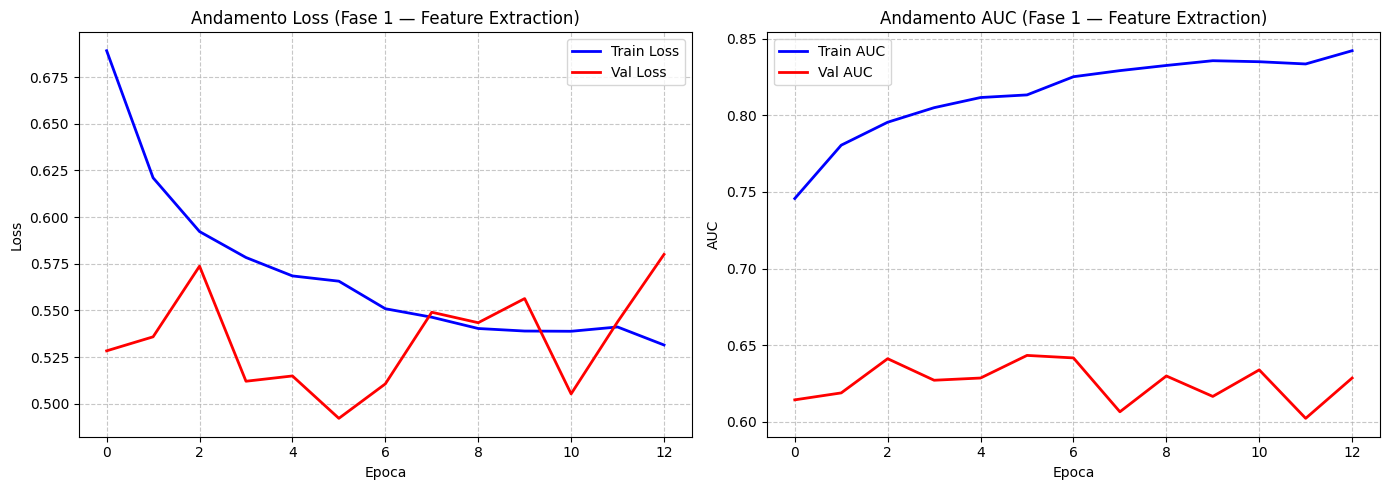

Analisi Overfitting - Fase 2 (Fine Tuning):
Grafico salvato in: ../experiments/exp20260618_real_synth_resnet50_fine_tuned_all_layers/figures/training_history_fase2.png


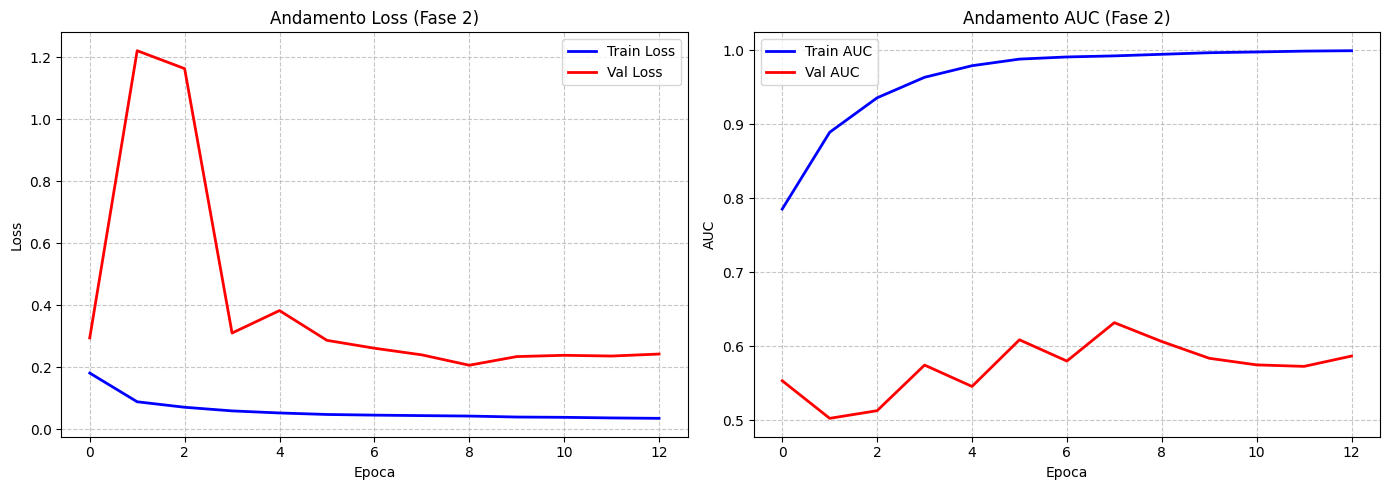

In [14]:
def plot_training_history(history, title_suffix="", save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_title(f'Andamento Loss {title_suffix}')
    ax1.set_xlabel('Epoca')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2.plot(history.history['auc'], label='Train AUC', color='blue', linewidth=2)
    ax2.plot(history.history['val_auc'], label='Val AUC', color='red', linewidth=2)
    ax2.set_title(f'Andamento AUC {title_suffix}')
    ax2.set_xlabel('Epoca')
    ax2.set_ylabel('AUC')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Grafico salvato in: {save_path}")
    plt.show()

FIGURES_DIR = os.path.join(OUTPUT_EXP_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Analisi Overfitting - Fase 1 (Feature Extraction):")
plot_training_history(
    history_phase1, "(Fase 1 — Feature Extraction)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase1.png')
)

print("Analisi Overfitting - Fase 2 (Fine Tuning):")
plot_training_history(
    history_phase2, "(Fase 2)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase2.png')
)

#### Valutazione sul Validation Set

Carica il miglior modello salvato e calcola le predizioni sull'intero validation set

- **Soglia ottimale**: determinata con l'indice di Youden (massimizza sensibilità + specificità), più adatta della soglia fissa 0.5 su dataset sbilanciati. Bilancia meglio i falsi negativi (tumori mancati) e falsi positivi
- **Metriche**: AUC, precision, recall e F1 calcolate sulla classe positiva (cancro) e salvate in `val_metrics.json`
- **Figure**: Confusion Matrix e ROC Curve salvate in `figures/`


AUC: 0.6309
Soglia ottimale: 0.161
              precision    recall  f1-score   support

   No cancro       0.90      0.63      0.74       364
      Cancro       0.26      0.64      0.37        73

    accuracy                           0.63       437
   macro avg       0.58      0.64      0.55       437
weighted avg       0.79      0.63      0.68       437

Metriche salvate in: ../experiments/exp20260618_real_synth_resnet50_fine_tuned_all_layers/val_metrics.json


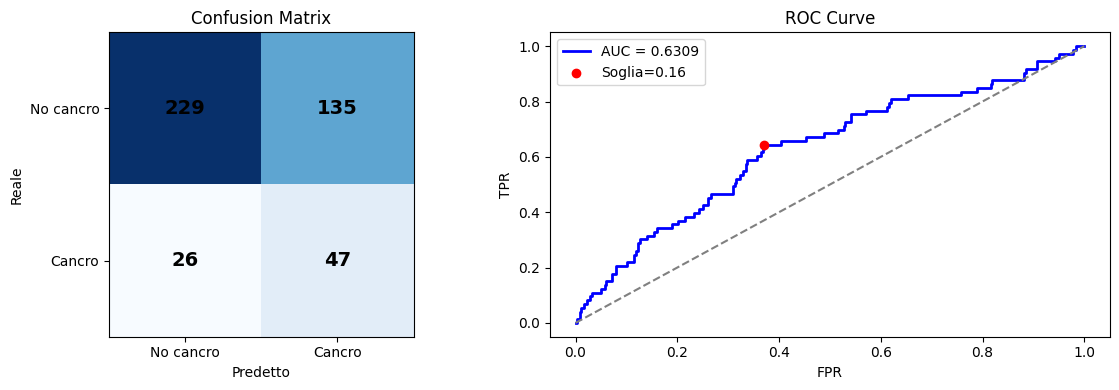

Figura salvata in: ../experiments/exp20260618_real_synth_resnet50_fine_tuned_all_layers/figures/val_confusion_roc.png


In [ ]:
from sklearn.metrics import (confusion_matrix, roc_curve,
                             classification_report, roc_auc_score,
                             precision_score, recall_score, f1_score)

# Carica il miglior modello salvato
best_model = keras.models.load_model(
    os.path.join(OUTPUT_EXP_DIR, 'real_synth_resnet50_all_layers_final_best.keras')
)

# Predizioni sul validation set
y_true, y_pred_prob = [], []
for imgs, labels in val_ds:
    preds = best_model.predict(imgs, verbose=0)
    y_pred_prob.extend(preds.flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Soglia ottimale (Youden's J)
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
youden_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[youden_idx]
y_pred = (y_pred_prob >= best_threshold).astype(int)

val_auc = roc_auc_score(y_true, y_pred_prob)
report_str = classification_report(y_true, y_pred, target_names=['No cancro', 'Cancro'])

print(f"AUC: {val_auc:.4f}")
print(f"Soglia ottimale: {best_threshold:.3f}")
print(report_str)

# Salva metriche in JSON
FIGURES_DIR = os.path.join(OUTPUT_EXP_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

metrics_dict = {
    'split': 'validation',
    'backbone': 'ResNet-50',
    'experiment_name': os.path.basename(OUTPUT_EXP_DIR),
    'auc': round(float(val_auc), 4),
    'optimal_threshold_youden': round(float(best_threshold), 4),
    'accuracy': round(float((y_pred == y_true).mean()), 4),
    'precision_cancer': round(float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'recall_cancer':    round(float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'f1_cancer':        round(float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'classification_report': report_str,
}
metrics_path = os.path.join(OUTPUT_EXP_DIR, 'val_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)
print(f"Metriche salvate in: {metrics_path}")

# Figura: Confusion Matrix + ROC curve
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No cancro', 'Cancro'])
axes[0].set_yticklabels(['No cancro', 'Cancro'])
axes[0].set_xlabel('Predetto'); axes[0].set_ylabel('Reale')
axes[0].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, fontweight='bold')

axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {val_auc:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].scatter(fpr[youden_idx], tpr[youden_idx], color='red', zorder=5, label=f'Soglia={best_threshold:.2f}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'val_confusion_roc.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura salvata in: {fig_path}")

#### Grad-CAM — Interpretabilità del Modello

Visualizza le regioni dell'immagine che hanno maggiormente influenzato la predizione, calcolando i gradienti dell'output rispetto alle feature map finali del backbone.

Per ogni campione vengono mostrati: immagine originale con heatmap sovrapposta e heatmap isolata.
Utile per verificare che il modello si concentri su aree anatomicamente rilevanti anziché su artefatti.


Modello caricato: real_synth_resnet50_all_layers


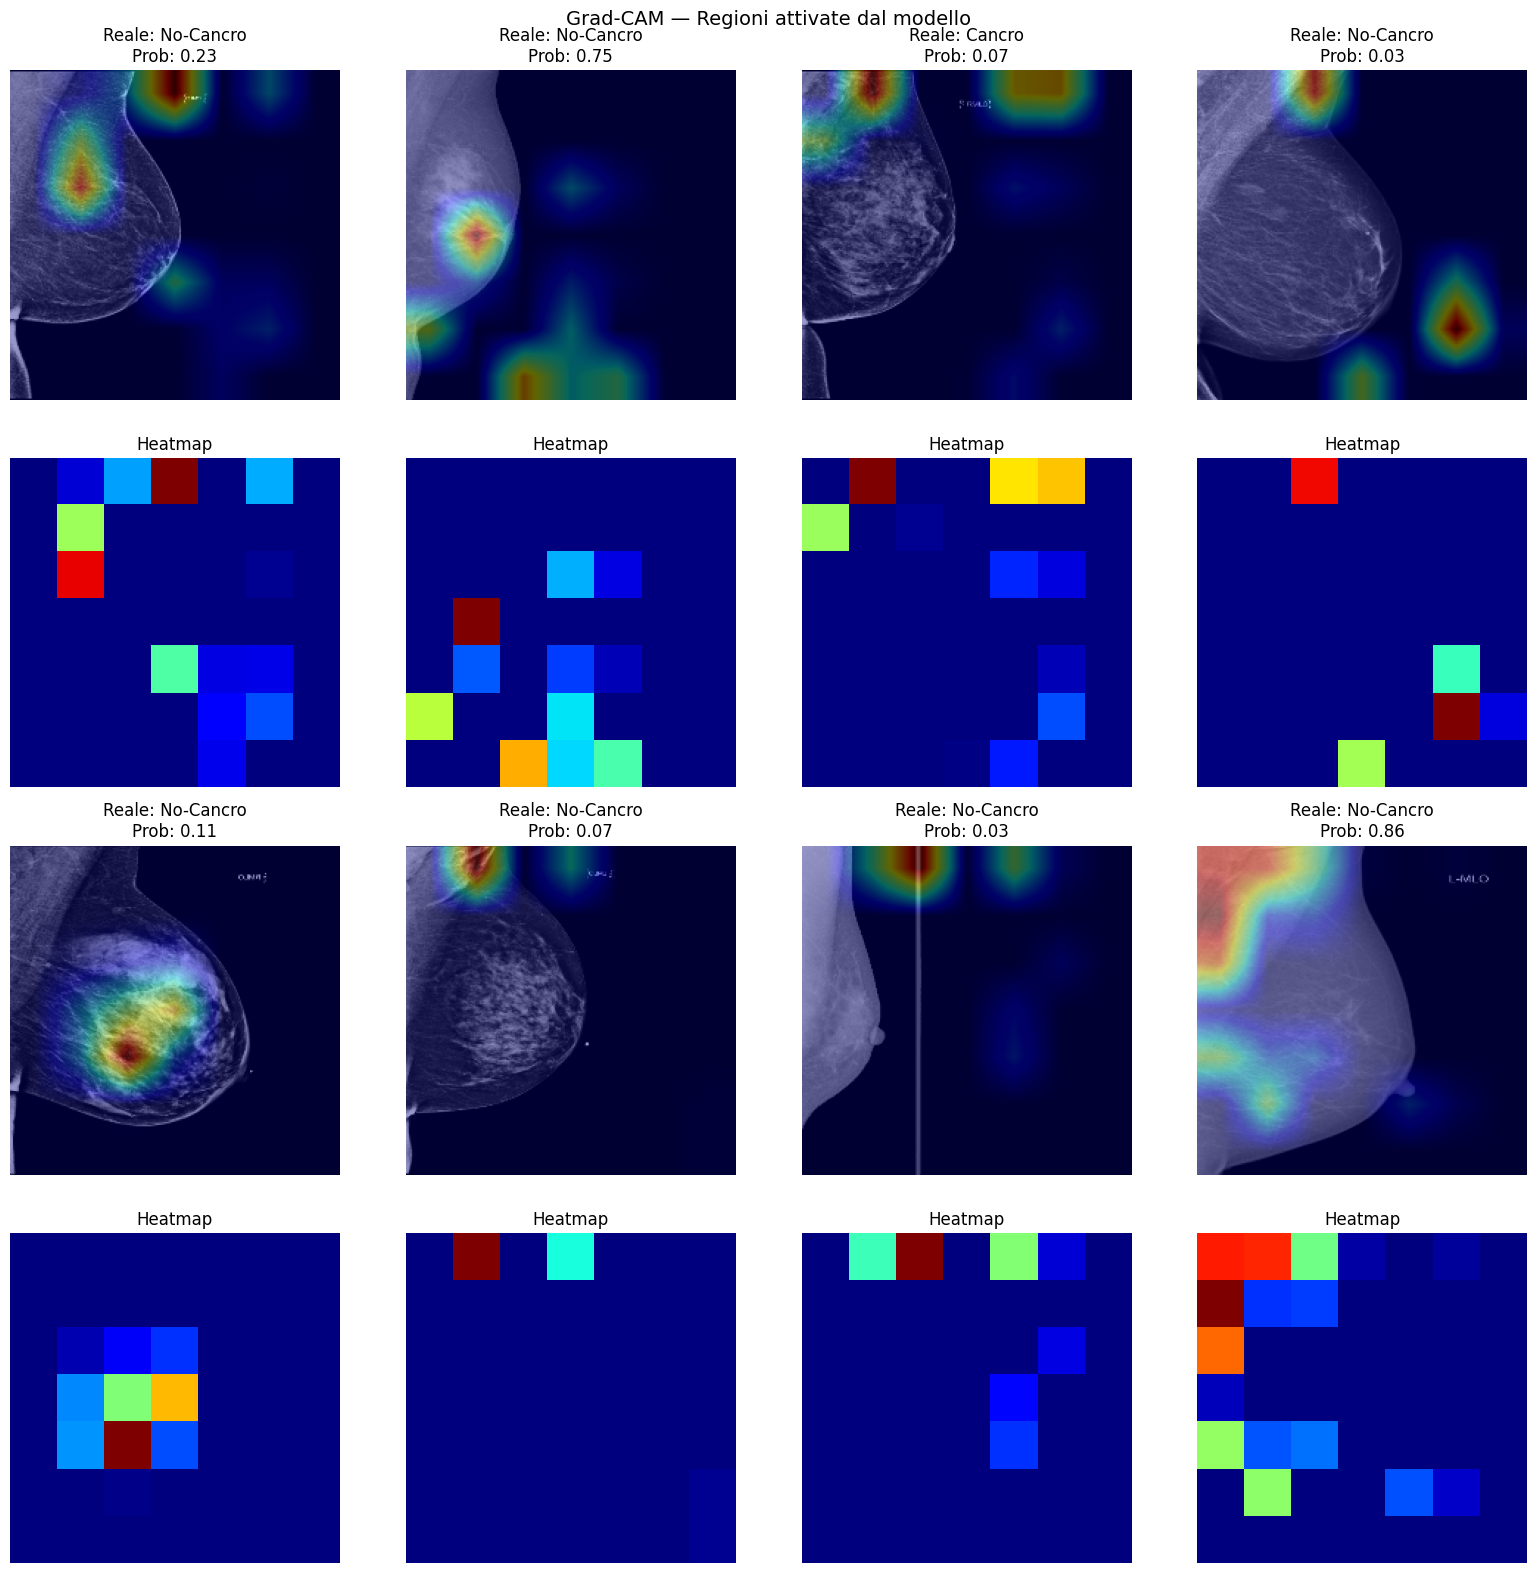

Grad-CAM salvato in: ../experiments/exp20260618_real_synth_resnet50_fine_tuned_all_layers/figures/gradcam_examples.png


In [ ]:
# Carica il modello già allenato
FIGURES_DIR = os.path.join(OUTPUT_EXP_DIR, 'figures')

best_model = keras.models.load_model(
    os.path.join(OUTPUT_EXP_DIR, 'real_synth_resnet50_all_layers_final_best.keras')
)
print(f"Modello caricato: {best_model.name}")


def make_gradcam_heatmap(img_array, model):
    backbone = model.get_layer('resnet50')
    head_layers = [l for l in model.layers
                   if l.name not in [model.layers[0].name, backbone.name]]

    with tf.GradientTape() as tape:
        backbone_out = backbone(img_array, training=False)
        tape.watch(backbone_out)
        x = backbone_out
        for layer in head_layers:
            x = layer(x, training=False)
        predictions = x

    grads = tape.gradient(predictions, backbone_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = backbone_out[0] @ pooled_grads[..., tf.newaxis] # Combinazione pesata delle feature map: canali più rilevanti contribuiscono di più
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()



def show_gradcam(img_tensor, heatmap, ax, title=""):
    img_vis = img_tensor.numpy() * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img_vis = np.clip(img_vis, 0, 1)
    img_vis_gray = img_vis[:, :, 0]  # canale singolo (mammografia)

    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    ax.imshow(img_vis_gray, cmap='gray')
    ax.imshow(heatmap_resized, cmap='jet', alpha=0.4)
    ax.set_title(title)
    ax.axis('off')


# Mostra Grad-CAM su 8 esempi del validation set
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
sample_count = 0
for imgs, labels in val_ds:
    for i in range(len(imgs)):
        if sample_count >= 8:
            break
        img = imgs[i:i+1]
        label = int(labels[i].numpy())
        prob = float(best_model.predict(img, verbose=0)[0][0])
        heatmap = make_gradcam_heatmap(img, best_model)

        row_img = (sample_count // 4) * 2       
        row_heat = row_img + 1                  
        col = sample_count % 4                  

        show_gradcam(imgs[i], heatmap, axes[row_img, col],
                     title=f"Reale: {'Cancro' if label==1 else 'No-Cancro'}\nProb: {prob:.2f}")
        axes[row_heat, col].imshow(heatmap, cmap='jet')
        axes[row_heat, col].set_title("Heatmap")
        axes[row_heat, col].axis('off')
        sample_count += 1
    if sample_count >= 8:
        break

plt.suptitle("Grad-CAM — Regioni attivate dal modello", fontsize=14)
plt.tight_layout()
gradcam_path = os.path.join(FIGURES_DIR, 'gradcam_examples.png')
fig.savefig(gradcam_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grad-CAM salvato in: {gradcam_path}")

#### Grad-CAM su immagini sintetiche

Applica Grad-CAM a 8 immagini sintetiche campionate casualmente (seed fisso).
Per ogni campione mostra immagine originale con heatmap sovrapposta e heatmap isolata, organizzate in una griglia 4×4 (riga pari = immagine, riga dispari = heatmap).

Permette di verificare se il modello attiva regioni anatomicamente plausibili anche sulle immagini generate, validando la qualità delle sintetiche dal punto di vista del classificatore.


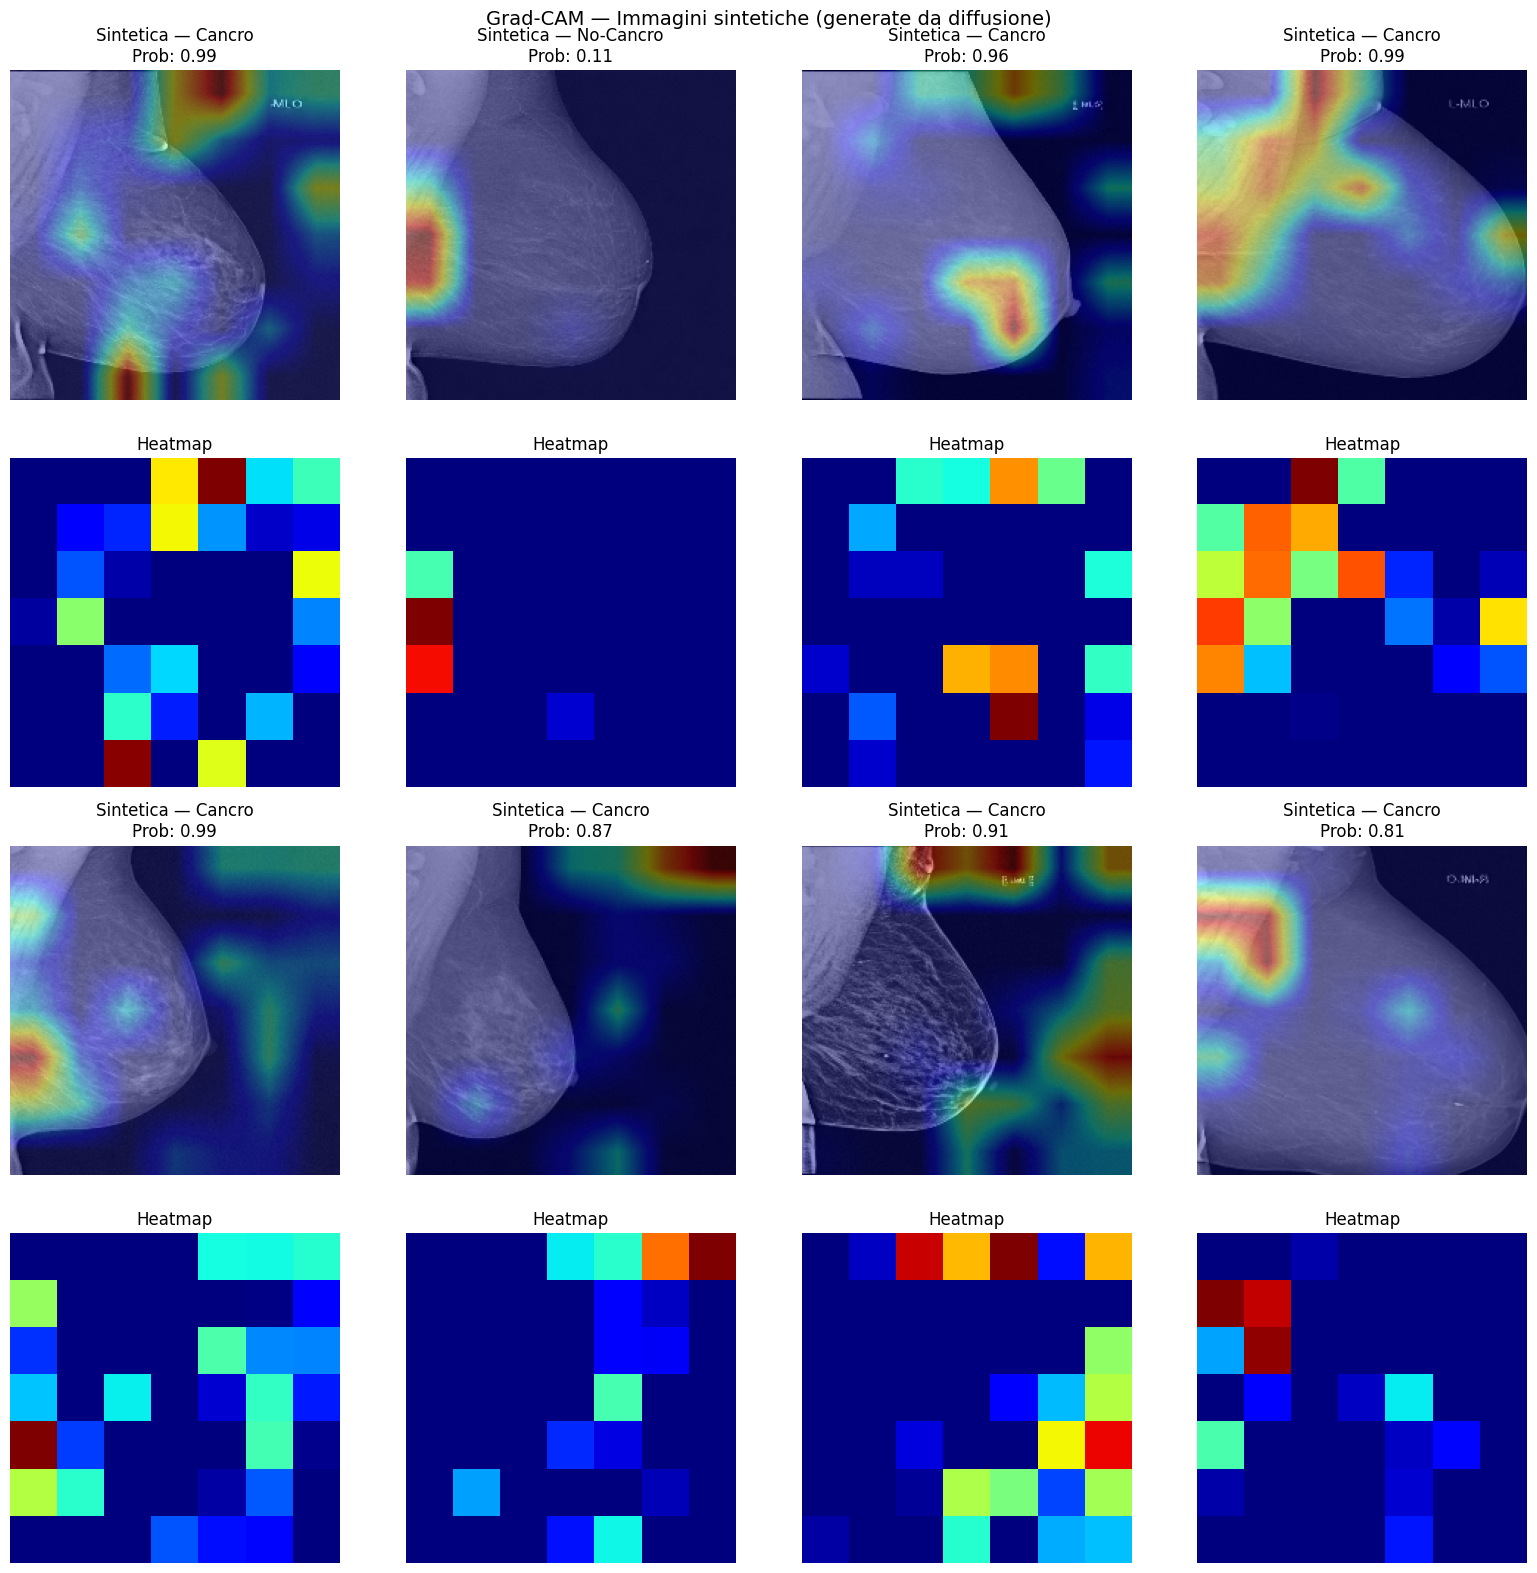

Grad-CAM sintetiche salvato in: ../experiments/exp20260618_real_synth_resnet50_fine_tuned_all_layers/figures/gradcam_synthetic_examples.png


In [ ]:
# Dataset con sole immagini sintetiche
df_synth = pd.concat([df_synth_pos_df, df_synth_neg_df], ignore_index=True)
synth_ds = make_dataset(df_synth[['processed_path', 'cancer']], shuffle=False, augment_data=False)

# Raccoglie tutte le immagini sintetiche e campiona 8 casuali
all_synth_imgs, all_synth_labels = [], []
for imgs, labels in synth_ds:
    for i in range(len(imgs)):
        all_synth_imgs.append(imgs[i])
        all_synth_labels.append(int(labels[i].numpy()))

np.random.seed(SEED)  # per avere riproducibilità
indices_synth = np.random.choice(len(all_synth_imgs), size=8, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for i, idx in enumerate(indices_synth):
    img = tf.expand_dims(all_synth_imgs[idx], 0)
    label = all_synth_labels[idx]
    prob = float(best_model.predict(img, verbose=0)[0][0])
    heatmap = make_gradcam_heatmap(img, best_model)

    row_img = (i // 4) * 2      
    row_heat = row_img + 1      
    col = i % 4                 

    show_gradcam(all_synth_imgs[idx], heatmap, axes[row_img, col],
                 title=f"Sintetica — {'Cancro' if label==1 else 'No-Cancro'}\nProb: {prob:.2f}")
    axes[row_heat, col].imshow(heatmap, cmap='jet')
    axes[row_heat, col].set_title("Heatmap")
    axes[row_heat, col].axis('off')

plt.suptitle("Grad-CAM — Immagini sintetiche (generate da diffusione)", fontsize=14)
plt.tight_layout()
gradcam_synth_path = os.path.join(FIGURES_DIR, 'gradcam_synthetic_examples.png')
fig.savefig(gradcam_synth_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grad-CAM sintetiche salvato in: {gradcam_synth_path}")